# Autoregressive-residual static dRSA for image responses

This notebook asks whether the representational variance unique to each image-response timepoint is still explained by model layers. It first removes the component of each response predicted by its own causal past, then repeats the static dRSA analysis from `summary_figs_report.ipynb`. Raw static dRSA is retained as a baseline, so layer-wise timing shifts can be inspected directly.

The autoregressive fit is descriptive and in-sample: its residuals are linear innovations, not causal evidence.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import yaml
from scipy.ndimage import gaussian_filter1d

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "config.yaml").is_file():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find config.yaml above the notebook directory.")
    # end if PROJECT_ROOT.parent == PROJECT_ROOT
    PROJECT_ROOT = PROJECT_ROOT.parent
# end while not config.yaml exists
with open(PROJECT_ROOT / "config.yaml", "r") as file:
    config = yaml.safe_load(file)
# end with open

paths = config[ENV]["paths"]
sys.path.extend([paths["src_path"], paths["useful_stuff_path"]])

from image_processing.video_feature_extraction import (
    list_video_feature_files, load_aligned_video_features, match_feature_stimulus_names,
)
from project_specific_utils import autoregressive_regress_out, load_natraster
from useful_stuff.general_utils import TimeSeries, create_RDM
from useful_stuff.general_utils.RSA import dRSA


In [52]:
@dataclass
class Cfg:
    img_exp_name: str = "baby1_260718to27"
    image_prefix: str = "img_"
    image_2000ms_prefix: str = "img_2000ms_"
    image_2250ms_prefix: str = "img_2250ms_"
    good_channels: tuple[int, int] | None = (101, 109)
    image_crop_ms: int = 1000
    new_fs: float | None = 500
    signal_RDM_metric: str = "cosine_cnt"
    model_RDM_metric: str = "cosine_cnt"
    RSA_metric: str = "spearman"
    model_name: str = "dino_v3_h" #"ijepa_vith14_1k"
    model_dataset_name: str = "static_dynamic"
    model_pooling: str | None = "mean"
    model_features_dir: Path | None = None
    first_delay: int = 10
    n_delays: int = 1
    regression_type: str = "lr"
    fit_intercept: bool = False
    smoothing_samples: float = 3
    summary_window_ms: tuple[float, float] | None = None


cfg = Cfg()
img_natraster_mat_path = (
    Path(paths["data_path"]) / "data" / f"{cfg.img_exp_name}_natraster_img.mat"
)
cfg


Cfg(img_exp_name='baby1_260718to27', image_prefix='img_', image_2000ms_prefix='img_2000ms_', image_2250ms_prefix='img_2250ms_', good_channels=(101, 109), image_crop_ms=1000, new_fs=500, signal_RDM_metric='cosine_cnt', model_RDM_metric='cosine_cnt', RSA_metric='spearman', model_name='dino_v3_h', model_dataset_name='static_dynamic', model_pooling='mean', model_features_dir=None, first_delay=10, n_delays=1, regression_type='lr', fit_intercept=False, smoothing_samples=3, summary_window_ms=None)

## Load the standard image condition

Model features are taken from each matching movie's final frame, as in the summary-figures static dRSA analysis.

In [53]:
loaded_img_rasters, loaded_img_names = load_natraster(img_natraster_mat_path)
image_indices = [
    index for index, name in enumerate(loaded_img_names)
    if Path(name).stem.startswith(cfg.image_prefix)
    and not Path(name).stem.startswith(cfg.image_2000ms_prefix)
    and not Path(name).stem.startswith(cfg.image_2250ms_prefix)
]
if len(image_indices) < 2:
    raise ValueError("Need at least two standard-image stimuli for static dRSA.")
# end if len(image_indices)

image_rasters = loaded_img_rasters[:, :cfg.image_crop_ms, image_indices]
image_names = [loaded_img_names[index] for index in image_indices]
if cfg.good_channels is not None:
    first_channel, last_channel = cfg.good_channels
    image_rasters = image_rasters[first_channel - 1:last_channel]
# end if cfg.good_channels is not None

image_ts = TimeSeries(image_rasters, fs=1000)
if cfg.new_fs is not None:
    image_ts.resample(cfg.new_fs)
# end if cfg.new_fs is not None

print(f"Static image response: {image_ts.shape()} (channels, time, stimuli)")


Static image response: (9, 500, 100) (channels, time, stimuli)


AR lags: [10] samples; residual starts at 20 ms
Mean channel-wise variance removed: 0.504
Residual response: (9, 490, 100) (channels, time, stimuli)


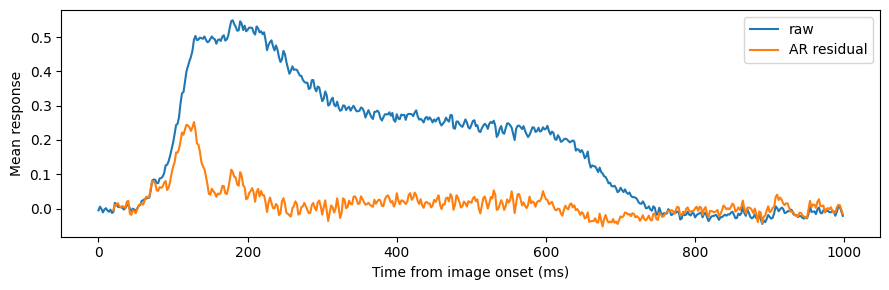

In [54]:
image_residual_ts, ar_model, variance_explained = autoregressive_regress_out(
    image_ts,
    first_delay=cfg.first_delay,
    n_delays=cfg.n_delays,
    regression_type=cfg.regression_type,
    fit_intercept=cfg.fit_intercept,
)
ar_lags = list(range(cfg.first_delay, cfg.first_delay + cfg.n_delays))
residual_start_ms = ar_lags[-1] * 1000 / image_ts.get_fs()
print(f"AR lags: {ar_lags} samples; residual starts at {residual_start_ms:g} ms")
print(f"Mean channel-wise variance removed: {variance_explained.mean():.3f}")
print(f"Residual response: {image_residual_ts.shape()} (channels, time, stimuli)")

fig, ax = plt.subplots(figsize=(9, 3))
time_ms = np.arange(len(image_ts)) * 1000 / image_ts.get_fs()
residual_time_ms = residual_start_ms + np.arange(len(image_residual_ts)) * 1000 / image_residual_ts.get_fs()
ax.plot(time_ms, image_ts.get_array().mean(axis=(0, 2)), label="raw")
ax.plot(residual_time_ms, image_residual_ts.get_array().mean(axis=(0, 2)), label="AR residual")
ax.set(xlabel="Time from image onset (ms)", ylabel="Mean response")
ax.legend()
fig.tight_layout()


## Static dRSA for raw and autoregressive-residual responses

In [55]:
model_features_dir = cfg.model_features_dir or Path(paths["data_path"]) / "models"
feature_paths = list_video_feature_files(
    model_features_dir, cfg.model_name, cfg.model_dataset_name, cfg.model_pooling,
)

# Resolve the image-session names to the exact HDF5 dataset names once.
model_stimulus_names = match_feature_stimulus_names(feature_paths[0], image_names)
raw_drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.model_RDM_metric,
    RSA_metric=cfg.RSA_metric,
)
residual_drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.model_RDM_metric,
    RSA_metric=cfg.RSA_metric,
)
raw_drsa.compute_RDM_timeseries(image_ts, "signal")
residual_drsa.compute_RDM_timeseries(image_residual_ts, "signal")

raw_layer_drsa = []
residual_layer_drsa = []
layer_names = []
for feature_path in feature_paths:
    final_frame_features, layer_name, _ = load_aligned_video_features(
        feature_path, model_stimulus_names, frame_index=-1,
    )
    model_RDM = create_RDM(final_frame_features, metric=cfg.model_RDM_metric)
    raw_drsa.set_RDM(model_RDM, "model")
    residual_drsa.set_RDM(model_RDM, "model")
    raw_layer_drsa.append(raw_drsa.compute_static_dRSA().get_array().copy())
    residual_layer_drsa.append(
        residual_drsa.compute_static_dRSA().get_array().copy()
    )
    layer_names.append(layer_name)
# end for feature_path

raw_layer_drsa = np.stack(raw_layer_drsa)
residual_layer_drsa = np.stack(residual_layer_drsa)
print(f"Raw static dRSA: {raw_layer_drsa.shape} (layers, time)")
print(f"Residual static dRSA: {residual_layer_drsa.shape} (layers, time)")


Raw static dRSA: (32, 500) (layers, time)
Residual static dRSA: (32, 490) (layers, time)


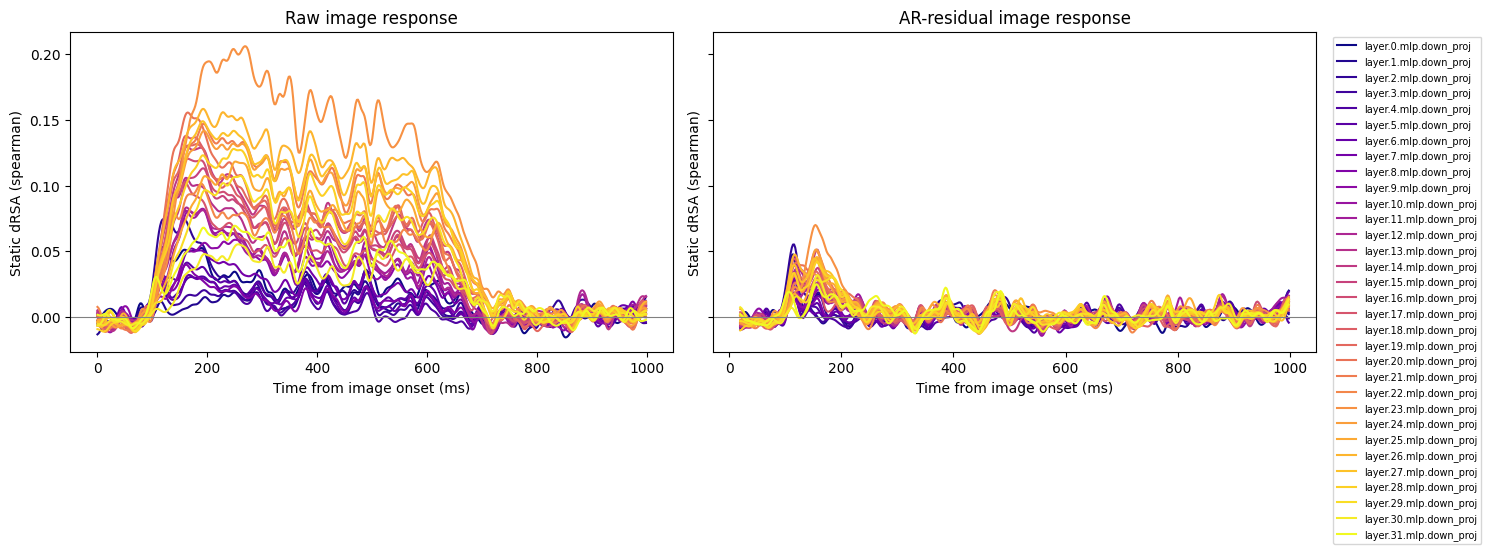

In [56]:
raw_time_ms = np.arange(raw_layer_drsa.shape[1]) * 1000 / image_ts.get_fs()
residual_time_ms = (
    residual_start_ms
    + np.arange(residual_layer_drsa.shape[1]) * 1000 / image_residual_ts.get_fs()
)
layer_colors = plt.cm.plasma(np.linspace(0, 1, len(layer_names)))

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for layer_index, layer_name in enumerate(layer_names):
    raw_curve = gaussian_filter1d(
        raw_layer_drsa[layer_index], sigma=cfg.smoothing_samples,
    )
    residual_curve = gaussian_filter1d(
        residual_layer_drsa[layer_index], sigma=cfg.smoothing_samples,
    )
    axes[0].plot(raw_time_ms, raw_curve, color=layer_colors[layer_index], label=layer_name)
    axes[1].plot(residual_time_ms, residual_curve, color=layer_colors[layer_index], label=layer_name)
# end for layer_index
for ax, title in zip(axes, ["Raw image response", "AR-residual image response"]):
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.set(xlabel="Time from image onset (ms)", ylabel=f"Static dRSA ({cfg.RSA_metric})", title=title)
# end for ax, title
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
fig.tight_layout()


{'layer.0.mlp.down_proj': {'raw_centroid_ms': np.float64(357.21202344619326),
  'residual_centroid_ms': np.float64(389.27189228154907),
  'centroid_shift_ms': np.float64(32.059868835355815),
  'raw_peak_ms': np.float64(118.0),
  'residual_peak_ms': np.float64(114.0),
  'peak_shift_ms': np.float64(-4.0)},
 'layer.1.mlp.down_proj': {'raw_centroid_ms': np.float64(425.9014588187113),
  'residual_centroid_ms': np.float64(506.1432515051008),
  'centroid_shift_ms': np.float64(80.24179268638949),
  'raw_peak_ms': np.float64(380.0),
  'residual_peak_ms': np.float64(116.0),
  'peak_shift_ms': np.float64(-264.0)},
 'layer.2.mlp.down_proj': {'raw_centroid_ms': np.float64(327.8412036010168),
  'residual_centroid_ms': np.float64(369.95903282779295),
  'centroid_shift_ms': np.float64(42.117829226776166),
  'raw_peak_ms': np.float64(120.0),
  'residual_peak_ms': np.float64(116.0),
  'peak_shift_ms': np.float64(-4.0)},
 'layer.3.mlp.down_proj': {'raw_centroid_ms': np.float64(365.29110831642566),
  'res

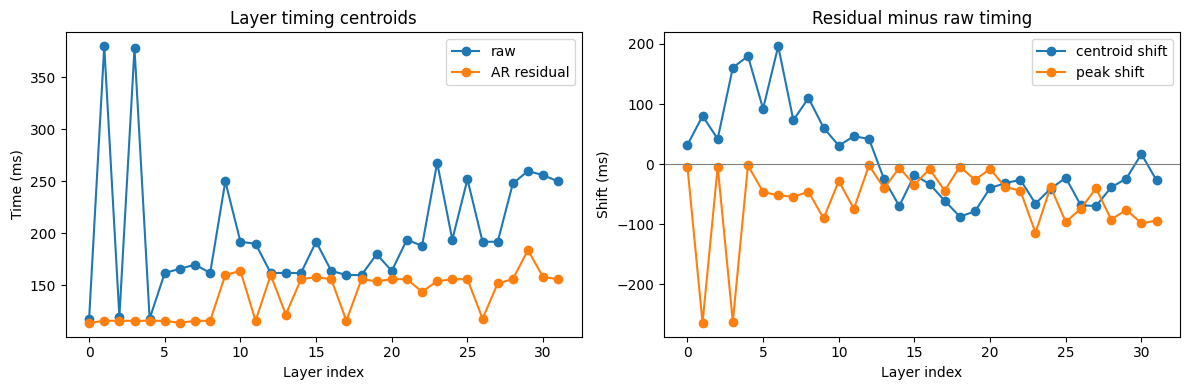

In [57]:
"""
positive_mass_timing
Summarize a dRSA curve by its positive-mass centroid and peak time.

INPUT:
    - curve: np.ndarray -> one time-resolved dRSA curve.
    - time_ms: np.ndarray -> time coordinate for every curve sample.
    - summary_window_ms: tuple[float, float] | None -> optional inclusive time window.

OUTPUT:
    - centroid_ms: float -> positive-mass timing centroid, or NaN when no mass exists.
    - peak_ms: float -> time of the largest positive dRSA value, or NaN.
"""
def positive_mass_timing(curve, time_ms, summary_window_ms=None):
    if summary_window_ms is None:
        valid_indices = np.ones(len(time_ms), dtype=bool)
    else:
        start_ms, end_ms = summary_window_ms
        valid_indices = (time_ms >= start_ms) & (time_ms <= end_ms)
    # end if summary_window_ms is None
    positive_curve = np.maximum(curve[valid_indices], 0)
    valid_time_ms = time_ms[valid_indices]
    if not positive_curve.any():
        return np.nan, np.nan
    # end if not positive_curve.any
    centroid_ms = np.average(valid_time_ms, weights=positive_curve)
    peak_ms = valid_time_ms[np.argmax(positive_curve)]
    return centroid_ms, peak_ms
# EOF

raw_centroids_ms, raw_peaks_ms = [], []
residual_centroids_ms, residual_peaks_ms = [], []
for raw_curve, residual_curve in zip(raw_layer_drsa, residual_layer_drsa):
    raw_curve = gaussian_filter1d(raw_curve, sigma=cfg.smoothing_samples)
    residual_curve = gaussian_filter1d(residual_curve, sigma=cfg.smoothing_samples)
    raw_centroid, raw_peak = positive_mass_timing(raw_curve, raw_time_ms, cfg.summary_window_ms)
    residual_centroid, residual_peak = positive_mass_timing(
        residual_curve, residual_time_ms, cfg.summary_window_ms,
    )
    raw_centroids_ms.append(raw_centroid)
    raw_peaks_ms.append(raw_peak)
    residual_centroids_ms.append(residual_centroid)
    residual_peaks_ms.append(residual_peak)
# end for raw_curve, residual_curve

layer_index = np.arange(len(layer_names))
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
axes[0].plot(layer_index, raw_peaks_ms, "o-", label="raw")
axes[0].plot(layer_index, residual_peaks_ms, "o-", label="AR residual")
axes[0].set(title="Layer timing centroids", xlabel="Layer index", ylabel="Time (ms)")
axes[0].legend()
axes[1].plot(layer_index, np.subtract(residual_centroids_ms, raw_centroids_ms), "o-", label="centroid shift")
axes[1].plot(layer_index, np.subtract(residual_peaks_ms, raw_peaks_ms), "o-", label="peak shift")
axes[1].axhline(0, color="grey", linewidth=0.8)
axes[1].set(title="Residual minus raw timing", xlabel="Layer index", ylabel="Shift (ms)")
axes[1].legend()
fig.tight_layout()

layer_timing = {
    layer_name: {
        "raw_centroid_ms": raw_centroid,
        "residual_centroid_ms": residual_centroid,
        "centroid_shift_ms": residual_centroid - raw_centroid,
        "raw_peak_ms": raw_peak,
        "residual_peak_ms": residual_peak,
        "peak_shift_ms": residual_peak - raw_peak,
    }
    for layer_name, raw_centroid, residual_centroid, raw_peak, residual_peak in zip(
        layer_names, raw_centroids_ms, residual_centroids_ms, raw_peaks_ms, residual_peaks_ms,
    )
}
layer_timing
